# Lecture: Comparing Distributions Across Groups

In the previous lecture, we compared two categorical features. Here we compare the distribution of one quantitative feature across categorical groups while following the same reproducible analysis workflow.


## Learning goals

- compare groups using center, spread, shape, overlap, and unusual values;
- create histograms, box plots, and violin plots with Seaborn;
- explain the strengths and limitations of each plot;
- interpret daily values that summarize many individual flights; and
- state a supported conclusion and limitation.


## Prepare the notebook

**Seaborn** is a visualization library built on Matplotlib. It works especially well with Pandas DataFrames and makes statistical comparisons among groups easier to create with concise code.

Import Pandas using its conventional alias `pd`, Matplotlib's `pyplot` component using its conventional alias `plt`, and Seaborn using its conventional alias `sns`.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Airport taxi-in times in 2025

The Bureau of Transportation Statistics collects on-time performance for nonstop domestic flights reported by covered U.S. airlines. The dataset summarizes those flight records by destination airport and date.

We will compare four major airports with visibly different taxi-in patterns:

- `MIA`: Miami International;
- `MCO`: Orlando International;
- `DFW`: Dallas–Fort Worth International; and
- `ORD`: Chicago O'Hare International.

Source: https://www.transtats.bts.gov/ONTIME/


## What is taxi-in time?

Taxi-in time is the number of minutes from **wheels-on**—when an arriving aircraft reaches the runway—to its arrival at the gate. It is the part of the trip after landing but before passengers can leave the aircraft.

The dataset contains the mean taxi-in time among completed, non-diverted arrivals for each airport and date. Therefore, one value such as `12.4` means that arriving flights took an average of 12.4 minutes to travel from the runway to the gate at that airport on that date.


## The reproducible analysis workflow

1. **Question**
2. **Data**
3. **Operation**
4. **Check**
5. **Evidence**
6. **Conclusion**
7. **Limitation**


## Step 1 — Question

> **How did average daily taxi-in times differ among Miami, Orlando, Dallas–Fort Worth, and Chicago O'Hare in 2025?**

Landing does not mark the end of a passenger's trip. Airport layout, runway configuration, congestion, and gate availability can affect how long an aircraft spends traveling to the gate. Comparing complete distributions reveals typical differences as well as unusually slow days.


## Step 2 — Data


In [3]:
airport_days = pd.read_csv('data/bts_airport_daily_delays_2025.csv', parse_dates=['date'])

airport_days.head()

,airport_code,airport,date,month,day_of_week,scheduled_arrivals,completed_arrivals,mean_arrival_delay_min,median_arrival_delay_min,p90_arrival_delay_min,...,percent_arriving_15plus_min_late,mean_departure_delay_min,mean_taxi_in_min,cancellation_percent,diversion_percent,carrier_delay_min_per_scheduled_arrival,weather_delay_min_per_scheduled_arrival,nas_delay_min_per_scheduled_arrival,security_delay_min_per_scheduled_arrival,late_aircraft_delay_min_per_scheduled_arrival
0,ATL,Atlanta,2025-01-01,January,Wednesday,767.0,767.0,-6.636245,-13.0,15.0,...,10.299870,3.578879,9.096480,0.000000,0.000000,3.473272,0.054759,1.159061,0.000000,1.275098
1,ATL,Atlanta,2025-01-02,January,Thursday,946.0,942.0,-1.770701,-10.0,25.0,...,13.588110,6.673036,9.933121,0.422833,0.000000,2.341438,1.246300,1.160677,0.026427,3.520085
2,ATL,Atlanta,2025-01-03,January,Friday,941.0,941.0,1.741764,-7.0,31.0,...,17.959617,8.679065,10.383634,0.000000,0.000000,5.256111,0.420829,1.861849,0.000000,3.121148
3,ATL,Atlanta,2025-01-04,January,Saturday,919.0,917.0,5.770992,-7.0,40.0,...,23.882225,14.386041,9.632497,0.217628,0.000000,5.513602,0.355822,2.211099,0.095756,5.828074
4,ATL,Atlanta,2025-01-05,January,Sunday,943.0,907.0,17.363837,-1.0,62.0,...,29.878721,20.175303,10.137817,3.605514,0.212089,8.509014,2.186638,3.468717,0.000000,7.519618


In [4]:
airport_days.info()

<class 'pandas.DataFrame'>
RangeIndex: 2555 entries, 0 to 2554
Data columns (total 21 columns):
 #   Column                                         Non-Null Count  Dtype         
---  ------                                         --------------  -----         
 0   airport_code                                   2555 non-null   str           
 1   airport                                        2555 non-null   str           
 2   date                                           2555 non-null   datetime64[us]
 3   month                                          2555 non-null   str           
 4   day_of_week                                    2555 non-null   str           
 5   scheduled_arrivals                             2555 non-null   float64       
 6   completed_arrivals                             2555 non-null   float64       
 7   mean_arrival_delay_min                         2555 non-null   float64       
 8   median_arrival_delay_min                       2555 non-null   float6

CSV files do not store a dedicated datetime data type, so Pandas would ordinarily read the dates as text. `parse_dates=["date"]` tells `read_csv()` to convert the `date` column to Pandas datetime values while loading the file. That conversion makes datetime tools such as `.dt.month` available later.


In [5]:
airport_days.tail()

,airport_code,airport,date,month,day_of_week,scheduled_arrivals,completed_arrivals,mean_arrival_delay_min,median_arrival_delay_min,p90_arrival_delay_min,...,percent_arriving_15plus_min_late,mean_departure_delay_min,mean_taxi_in_min,cancellation_percent,diversion_percent,carrier_delay_min_per_scheduled_arrival,weather_delay_min_per_scheduled_arrival,nas_delay_min_per_scheduled_arrival,security_delay_min_per_scheduled_arrival,late_aircraft_delay_min_per_scheduled_arrival
2550,ORD,Chicago O'Hare,2025-12-27,December,Saturday,947.0,912.0,19.169956,-2.0,77.9,...,32.236842,26.474781,16.951754,3.590285,0.105597,6.782471,2.553326,3.322070,0.000000,13.676874
2551,ORD,Chicago O'Hare,2025-12-28,December,Sunday,1008.0,933.0,66.064309,31.0,178.6,...,63.129689,58.408360,20.591640,5.853175,1.587302,8.330357,6.591270,17.396825,0.016865,30.525794
2552,ORD,Chicago O'Hare,2025-12-29,December,Monday,1011.0,929.0,62.648009,26.0,184.8,...,59.311087,58.354144,23.566200,8.011869,0.098912,12.679525,4.229476,8.167161,0.001978,34.375865
2553,ORD,Chicago O'Hare,2025-12-30,December,Tuesday,1002.0,957.0,47.608150,11.0,148.4,...,45.768025,40.929990,22.315569,2.295409,2.195609,14.671657,3.402196,10.671657,0.000000,20.200599
2554,ORD,Chicago O'Hare,2025-12-31,December,Wednesday,848.0,822.0,31.648418,5.0,109.9,...,39.902676,29.211679,20.447689,3.066038,0.000000,10.385613,2.536557,5.370283,0.003538,16.114387


In [6]:
airport_days.isnull().sum()

airport_code                                     0
airport                                          0
date                                             0
month                                            0
day_of_week                                      0
scheduled_arrivals                               0
completed_arrivals                               0
mean_arrival_delay_min                           0
median_arrival_delay_min                         0
p90_arrival_delay_min                            0
maximum_arrival_delay_min                        0
percent_arriving_15plus_min_late                 0
mean_departure_delay_min                         0
mean_taxi_in_min                                 0
cancellation_percent                             0
diversion_percent                                0
carrier_delay_min_per_scheduled_arrival          0
weather_delay_min_per_scheduled_arrival          0
nas_delay_min_per_scheduled_arrival              0
security_delay_min_per_schedule

## Data dictionary

The features used in this lesson are:

| Feature | Meaning |
| --- | --- |
| `airport` | Name of the destination airport |
| `date` | Calendar date |
| `month` | Month name |
| `day_of_week` | Day name |
| `mean_taxi_in_min` | Mean time from runway arrival to the gate |


## Discussion: check the data

Complete the table using `.info()`, `.isnull().sum()`, and the data dictionary. In the data type column, classify the feature as categorical, quantitative, or temporal. In the data storage type column, record the type reported by Pandas.

| Feature | Data type | Data storage type | Missing values |
| --- | --- | --- | ---: |
| `airport` | categorical | string | 0 |
| `date` | time | datetime | 0 |
| `month` | categorical | string | 0 |
| `day_of_week` | categorical | string | 0 |
| `mean_taxi_in_min` | quantitative | float64 | 0 |


**What does each record represent: one flight, one airport, or something more specific? How can you tell?**


**Notes and calculations:**


One airport on one day.

## Step 3 — Operation

Select the four airports. `.isin()` checks whether each airport name appears in our list.


In [7]:
airport_days['airport'].value_counts()

airport
Atlanta              365
Denver               365
Dallas-Fort Worth    365
Los Angeles          365
Orlando              365
Miami                365
Chicago O'Hare       365
Name: count, dtype: int64

In [8]:
# #target_airports = [
#     "Miami",
#     "Orlando",
#     "Dallas/Fort Worth",
#     "Chicago O'Hare",
# ]  # or check exact strings in 
# airport_days['airport'].unique()
# Alternatively using airport_code:
target_codes = ['MIA', 'MCO', 'DFW', 'ORD']
comparison = airport_days[airport_days['airport_code'].isin(target_codes)].copy()

# comparison = airport_days[airport_days["airport"].isin(airport_order)].copy()
comparison.head()


,airport_code,airport,date,month,day_of_week,scheduled_arrivals,completed_arrivals,mean_arrival_delay_min,median_arrival_delay_min,p90_arrival_delay_min,...,percent_arriving_15plus_min_late,mean_departure_delay_min,mean_taxi_in_min,cancellation_percent,diversion_percent,carrier_delay_min_per_scheduled_arrival,weather_delay_min_per_scheduled_arrival,nas_delay_min_per_scheduled_arrival,security_delay_min_per_scheduled_arrival,late_aircraft_delay_min_per_scheduled_arrival
730,DFW,Dallas-Fort Worth,2025-01-01,January,Wednesday,829.0,827.0,4.076179,-9.0,22.4,...,13.301088,11.234583,12.967352,0.120627,0.120627,7.728589,0.601930,1.069964,0.004825,4.310012
731,DFW,Dallas-Fort Worth,2025-01-02,January,Thursday,903.0,900.0,-1.527778,-10.0,26.0,...,16.333333,7.378889,12.033333,0.221484,0.110742,3.563677,0.471761,1.139535,0.016611,4.102990
732,DFW,Dallas-Fort Worth,2025-01-03,January,Friday,905.0,905.0,13.187845,-9.0,41.6,...,20.000000,22.333702,12.649724,0.000000,0.000000,12.500552,0.506077,1.724862,0.038674,8.408840
733,DFW,Dallas-Fort Worth,2025-01-04,January,Saturday,884.0,877.0,13.247434,-5.0,43.0,...,23.945268,18.966933,12.516534,0.678733,0.113122,7.358597,2.659502,2.958145,0.033937,7.728507
734,DFW,Dallas-Fort Worth,2025-01-05,January,Sunday,904.0,740.0,129.635135,107.5,269.0,...,76.216216,103.762162,18.698649,16.592920,1.548673,11.592920,20.046460,45.087389,0.127212,30.024336


Filtering can produce a DataFrame that still refers back to the original object's data. We add `.copy()` when we create `comparison` so it is an independent working DataFrame that could be modified without changing `airport_days` or triggering an ambiguous chained-assignment warning. We do not actually modify `comparison` in this analysis, so `.copy()` is not strictly necessary here. It becomes especially useful when you plan to add, remove, or change values in a filtered subset.

The frequency table confirms that every airport contributes the same number of daily records. Seaborn must also assign categorical labels to plot positions. Text categories normally follow their first appearance in the data unless a Pandas categorical order or an `order` argument supplies another order. We pass `airport_order` explicitly so every figure remains consistent.


## Discussion: predict the longest taxi time

Which airport do you predict will have the longest typical taxi-in time? What airport characteristic informed your prediction?


In [9]:
airport_code_order = ['ORD', 'DFW', 'MIA', 'MCO']
airport_order = ["Chicago O'Hare", "Dallas-Fort Worth", "Miami", "Orlando"]

comparison_airport = airport_days[airport_days['airport'].isin(airport_order)].copy()
comparison_airport.head()

,airport_code,airport,date,month,day_of_week,scheduled_arrivals,completed_arrivals,mean_arrival_delay_min,median_arrival_delay_min,p90_arrival_delay_min,...,percent_arriving_15plus_min_late,mean_departure_delay_min,mean_taxi_in_min,cancellation_percent,diversion_percent,carrier_delay_min_per_scheduled_arrival,weather_delay_min_per_scheduled_arrival,nas_delay_min_per_scheduled_arrival,security_delay_min_per_scheduled_arrival,late_aircraft_delay_min_per_scheduled_arrival
730,DFW,Dallas-Fort Worth,2025-01-01,January,Wednesday,829.0,827.0,4.076179,-9.0,22.4,...,13.301088,11.234583,12.967352,0.120627,0.120627,7.728589,0.601930,1.069964,0.004825,4.310012
731,DFW,Dallas-Fort Worth,2025-01-02,January,Thursday,903.0,900.0,-1.527778,-10.0,26.0,...,16.333333,7.378889,12.033333,0.221484,0.110742,3.563677,0.471761,1.139535,0.016611,4.102990
732,DFW,Dallas-Fort Worth,2025-01-03,January,Friday,905.0,905.0,13.187845,-9.0,41.6,...,20.000000,22.333702,12.649724,0.000000,0.000000,12.500552,0.506077,1.724862,0.038674,8.408840
733,DFW,Dallas-Fort Worth,2025-01-04,January,Saturday,884.0,877.0,13.247434,-5.0,43.0,...,23.945268,18.966933,12.516534,0.678733,0.113122,7.358597,2.659502,2.958145,0.033937,7.728507
734,DFW,Dallas-Fort Worth,2025-01-05,January,Sunday,904.0,740.0,129.635135,107.5,269.0,...,76.216216,103.762162,18.698649,16.592920,1.548673,11.592920,20.046460,45.087389,0.127212,30.024336


In [10]:
comparison['airport'].value_counts()

airport
Dallas-Fort Worth    365
Orlando              365
Miami                365
Chicago O'Hare       365
Name: count, dtype: int64

## Discussion: is the mean enough?

1. Does an airport's mean imply that taxi-in time is always that long?

2. What does the mean leave unanswered about how much taxi-in time fluctuates from day to day?

3. What additional features of each distribution should we compare?


In [11]:
taxi_summary = (
    comparison.groupby('airport')['mean_taxi_in_min'].mean().reindex(airport_order)
)

taxi_summary

airport
Chicago O'Hare       19.016515
Dallas-Fort Worth    13.634356
Miami                 9.760891
Orlando              10.589810
Name: mean_taxi_in_min, dtype: float64

## Step 4 — Check


In [12]:
comparison_airport['mean_taxi_in_min'].describe()

count    1460.000000
mean       13.250393
std         4.340035
min         7.076923
25%        10.015757
50%        12.487207
75%        14.798513
max        48.299145
Name: mean_taxi_in_min, dtype: float64

The earlier missing-value check found no missing values, and the frequency table confirmed that each airport contributes 365 dates. Because taxi-in time cannot be negative, the minimum and maximum from `.describe()` help us check that the observed range is possible and reasonable for daily averages.


## Step 5 — Evidence

### Histograms: detailed shape

The histogram divides taxi-in times into intervals called **bins**. The y-axis shows the number of days whose average taxi-in time falls within each bin. Because every airport contributes 365 days, the group counts are directly comparable.

The arguments used below control the plot:

- `x` selects the quantitative feature placed into bins;
- `hue` uses a different color for each airport and uses the feature name as the legend title;
- `hue_order` keeps the legend and drawing order consistent;
- `element="step"` draws each histogram with a stepped outline, making overlapping boundaries easier to distinguish;
- `multiple="layer"` places the airport histograms on the same axes so they can overlap;
- `alpha=0.45` makes the bars partly transparent—0 is completely transparent and 1 is completely opaque—so covered bars remain visible; and
- `palette="deep"` selects Seaborn's named set of colors.

Seaborn creates and labels a legend automatically when `hue` is used. `plt.gca().get_legend().set_title("Airport")` retrieves that existing legend and changes its title to the reader-friendly label `Airport`.


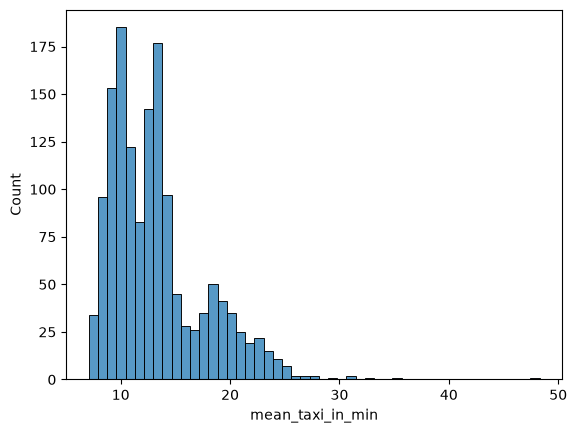

In [13]:
sns.histplot(data=comparison_airport, x='mean_taxi_in_min')

plt.show()

<Axes: ylabel='Frequency'>

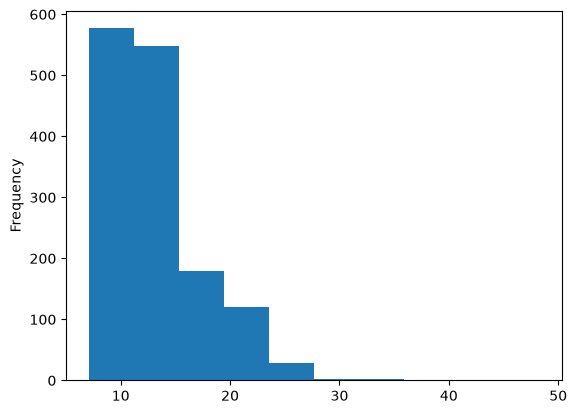

In [14]:
comparison_airport['mean_taxi_in_min'].plot(kind='hist')

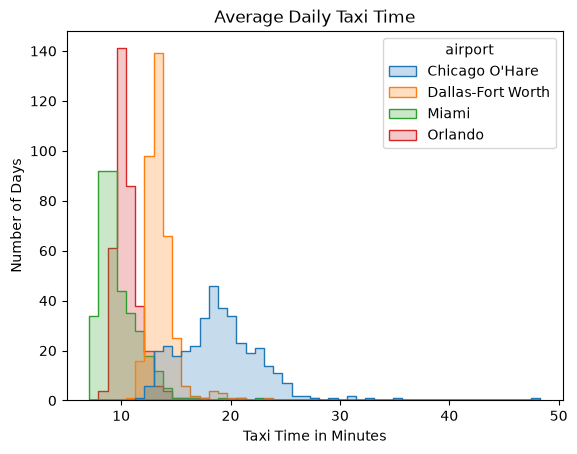

In [35]:
sns.histplot(data=comparison_airport, 
             x='mean_taxi_in_min',
             hue='airport',
             element='step',
             multiple='layer',
             hue_order=airport_order)

plt.title('Average Daily Taxi Time')
plt.xlabel('Taxi Time in Minutes')
plt.ylabel('Number of Days')
# plt.gca().get_legend().set_title('Airport')
plt.show()

## Discussion: interpret the histogram

1. Where does each airport's distribution appear to be centered?

2. Which distributions overlap substantially?

3. What information about shape is visible here that a single average would hide?


### Box plots: compact summaries

Statistician John Tukey developed the modern box plot as part of his approach to **exploratory data analysis**: using calculations and graphics to examine patterns before settling on an explanation or model. Tukey worked at Princeton and Bell Labs, contributed to the fast Fourier transform, and introduced the computing term *bit*. His work is an important bridge among statistics, data analysis, and computer science.

A box plot summarizes a distribution using several features:

- the line inside the box is the **median**, or 50th percentile;
- the two ends of the box are the **first quartile** (25th percentile) and **third quartile** (75th percentile);
- the length of the box is the **interquartile range**, or `IQR = Q3 - Q1`, containing the middle 50% of observations;
- the **whiskers** extend to the most extreme observed values within 1.5 IQRs of the box; and
- individual points beyond the whiskers are **potential outliers**.

“Potential outlier” is a reason to investigate a value, not proof that it is incorrect. The whiskers also do not automatically represent the minimum and maximum.


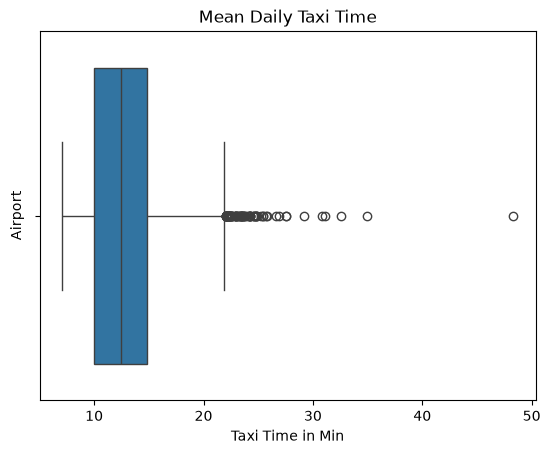

In [22]:
sns.boxplot(data=comparison,
            x='mean_taxi_in_min',
            # y='airport',
            # order=airport_order
            )

plt.title('Mean Daily Taxi Time')
plt.ylabel('Airport')
plt.xlabel('Taxi Time in Min')
plt.show()

## Discussion: histograms and box plots

1. Which distribution features are easier to see in the histograms?

2. Which distribution features are easier to see in the box plots?

3. What information does each figure make harder to see?


## Discussion: compare the box plots

1. Which airport has the greatest median taxi-in time?

2. Which airport has the widest middle 50% of days?

3. How do the potential outliers affect what you would say about a typical day?


### Violin plots: an attempt to combine both views

A violin plot attempts to combine the strengths of a histogram and a box plot in one figure: its width represents a smoothed estimate of the distribution's shape, while its interior provides a compact box-plot summary.


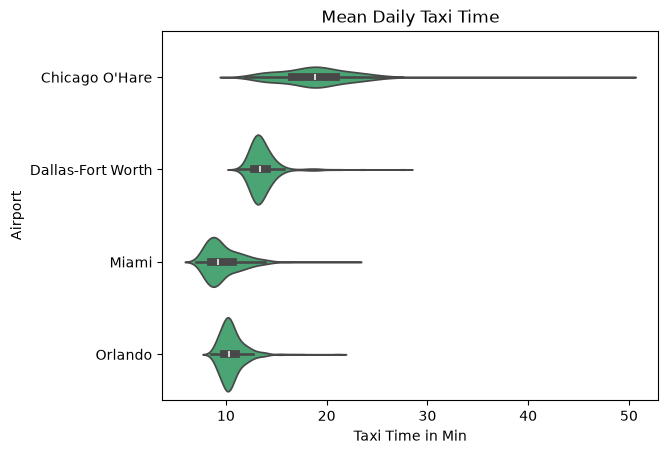

In [23]:
sns.violinplot(data=comparison_airport,
            x='mean_taxi_in_min',
            y='airport',
            order=airport_order,
            color='mediumseagreen')

plt.title('Mean Daily Taxi Time')
plt.ylabel('Airport')
plt.xlabel('Taxi Time in Min')
plt.show()

With its default settings, Seaborn draws a small box-plot summary inside each violin and allows the smoothed curve to extend beyond the most extreme observed values. Those extensions come from the density estimate; they are not additional observations.

**Strengths:** provides a compact comparison of smoothed shape and a box-plot summary.

**Limitations:** the density is estimated, smoothing can hide rare disruption days, and many audiences are unfamiliar with violin widths.


## Discussion: choose among the figures

Which figure would you choose to communicate the airport comparison to a general audience? What does your choice show especially well, and what does it hide?


### Investigate the longest taxi-in days

The figures show points or tails beyond the typical ranges. Now use `.nlargest()` to identify the days with the highest average taxi-in times. This lets us connect unusual marks in the figures back to actual observations.


## Step 6 — Conclusion

Taxi-in distributions differed substantially across the four airports. The box plots place Miami and Orlando lowest, Dallas–Fort Worth higher, and Chicago O'Hare highest in both center and spread. Chicago's middle 50% of days lies largely above the middle ranges at the other airports.

The histogram reveals distinct concentrations, the box plot makes the increasing centers and spreads easy to compare, and the violin plot emphasizes Chicago's broader distribution. All four airports also had occasional days well above their typical taxi-in times.


## Step 7 — Limitation

- BTS data cover reported nonstop domestic flights, not every passenger or international flight.
- Airport differences can reflect layout, runway and gate assignments, traffic volume, weather, schedules, and the mix of airlines.
- Each day receives equal weight in the distribution even though daily flight counts differ.
- A daily average hides variation among flights within that day and gives each day equal weight.
- A longer taxi-in time does not, by itself, demonstrate inefficiency or identify its cause.


# A Second Analysis: Orlando Scheduled Arrivals by Season

Orlando is a major destination for vacations, conventions, and holiday travel. That motivates a follow-up question about when the airport handled the most scheduled arrivals. Because seasons contain slightly different numbers of days, we will compare the distribution of **daily scheduled arrivals** rather than seasonal totals.


## Step 1 — Question

> **During which season did Orlando International have the greatest typical number of scheduled arrivals per day in 2025?**

Travel demand may change with school calendars, holidays, weather, and tourism patterns. The analysis can identify the observed seasonal pattern, although it cannot determine why that pattern occurred.


## Discussion: predict the busiest arrival season

Which season do you predict will have the greatest typical number of scheduled arrivals per day at Orlando? What informed your prediction?


## Step 2 — Data

Select Orlando from the same daily airport file. Each row still represents one date at one airport.


In [36]:
orlando = airport_days[airport_days['airport'] == 'Orlando'].copy()

orlando.head()

,airport_code,airport,date,month,day_of_week,scheduled_arrivals,completed_arrivals,mean_arrival_delay_min,median_arrival_delay_min,p90_arrival_delay_min,...,percent_arriving_15plus_min_late,mean_departure_delay_min,mean_taxi_in_min,cancellation_percent,diversion_percent,carrier_delay_min_per_scheduled_arrival,weather_delay_min_per_scheduled_arrival,nas_delay_min_per_scheduled_arrival,security_delay_min_per_scheduled_arrival,late_aircraft_delay_min_per_scheduled_arrival
1460,MCO,Orlando,2025-01-01,January,Wednesday,416.0,414.0,2.560386,-9.0,37.4,...,17.149758,8.053140,11.045894,0.480769,0.0,4.165865,0.000000,1.807692,0.000000,5.319712
1461,MCO,Orlando,2025-01-02,January,Thursday,485.0,484.0,5.099174,-5.5,32.7,...,18.181818,10.644628,11.264463,0.206186,0.0,5.432990,0.270103,1.882474,0.002062,4.740206
1462,MCO,Orlando,2025-01-03,January,Friday,476.0,476.0,4.052521,-8.0,40.0,...,20.798319,14.035714,11.451681,0.000000,0.0,4.796218,0.000000,1.701681,0.000000,7.144958
1463,MCO,Orlando,2025-01-04,January,Saturday,499.0,494.0,13.056680,-3.0,61.7,...,31.376518,21.273279,12.433198,1.002004,0.0,4.681363,0.657315,3.302605,0.106212,11.793587
1464,MCO,Orlando,2025-01-05,January,Sunday,486.0,468.0,17.055556,3.0,69.9,...,34.829060,19.314103,11.938034,3.703704,0.0,6.224280,1.179012,5.183128,0.010288,8.255144


In [37]:
orlando.value_counts()

airport_code  airport  date        month     day_of_week  scheduled_arrivals  completed_arrivals  mean_arrival_delay_min  median_arrival_delay_min  p90_arrival_delay_min  maximum_arrival_delay_min  percent_arriving_15plus_min_late  mean_departure_delay_min  mean_taxi_in_min  cancellation_percent  diversion_percent  carrier_delay_min_per_scheduled_arrival  weather_delay_min_per_scheduled_arrival  nas_delay_min_per_scheduled_arrival  security_delay_min_per_scheduled_arrival  late_aircraft_delay_min_per_scheduled_arrival
MCO           Orlando  2025-01-01  January   Wednesday    416.0               414.0               2.560386                -9.0                      37.4                   283.0                      17.149758                         8.053140                  11.045894         0.480769              0.0                4.165865                                 0.000000                                 1.807692                             0.000000                                

## Step 3 — Operation

### Create a season from a date

When the file was loaded, `parse_dates=["date"]` converted `date` from text into Pandas `datetime64` values. Datetime values have a `.dt` accessor that provides date-related properties and methods for an entire Series.

In `orlando["date"].dt.month`:

- `orlando["date"]` selects the date Series;
- `.dt` opens Pandas' datetime tools; and
- `.month` extracts the month number from every date, with January as 1 and December as 12.

We use meteorological seasons: winter is December–February, spring is March–May, summer is June–August, and fall is September–November.

A dictionary stores the season assigned to each month number. `.map()` looks up every extracted month number in that dictionary and returns its season. We save the result as a new `season` column.

Because this dataset is already aggregated, we assign a season to each daily summary. With the original flight-level records, the same `.dt.month.map(season_by_month)` expression could assign a season to each flight before aggregation.


In [38]:
# season_by_month  = {'December': 'Winter',
#                     'January' : 'Winter',
#                     'February' : 'Winter',
#                     'March' : 'Spring'
# }

season_by_month = {
    12: "Winter",
    1: "Winter",
    2: "Winter",
    3: "Spring",
    4: "Spring",
    5: "Spring",
    6: "Summer",
    7: "Summer",
    8: "Summer",
    9: "Fall",
    10: "Fall",
    11: "Fall",
}
orlando['season'] = orlando['date'].dt.month.map(season_by_month)
# orlando['season'] = orlando['month'].map(season_by_month)
orlando[['season','month']].head()

,season,month
1460,Winter,January
1461,Winter,January
1462,Winter,January
1463,Winter,January
1464,Winter,January


Store the seasons in chronological order. Without an explicit order, text categories may follow their first appearance in the data instead of the intended seasonal cycle.

`.reindex(season_order)` rearranges the completed summary table to match this order. The same method puts the `value_counts()` result into chronological order. It changes how the result is displayed, not the underlying Orlando rows or scheduled-arrival values.


In [39]:
season_order = ['Winter', 'Spring', 'Summer', 'Fall']

season_summary = orlando.groupby('season')['scheduled_arrivals'].mean().reindex(season_order)

season_summary

season
Winter    443.400000
Spring    465.652174
Summer    430.086957
Fall      414.285714
Name: scheduled_arrivals, dtype: float64

## Discussion: interpret the numerical summary

Based on the values calculated by `.describe()`, which season appears to have been busiest? What values support your answer?


## Step 4 — Check


The groups contain 90–92 days. These slight differences come from the number of calendar days in each season, not missing season assignments. All daily scheduled-arrival counts are positive. Comparing centers and complete distributions prevents a two-day difference in season length from deciding which season appears busiest.


## Step 5 — Evidence

### Histograms


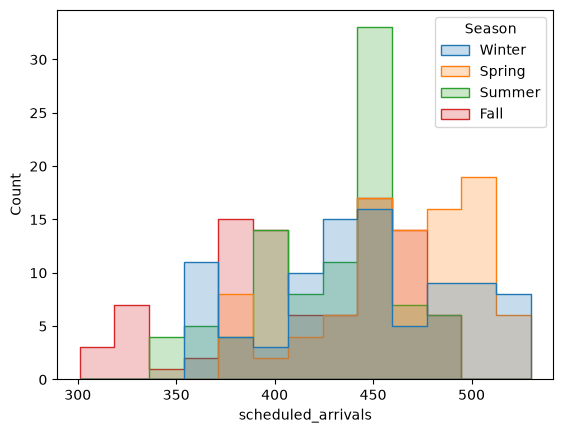

In [33]:
sns.histplot(data=orlando,
             x = 'scheduled_arrivals',
             hue = 'season',
             element='step',
             hue_order=season_order)

plt.gca().get_legend().set_title('Season')

## Discussion: compare the seasonal histograms

What can you conclude about seasonal scheduled arrivals from the histogram? What makes the comparison easy or difficult?


### Box plots


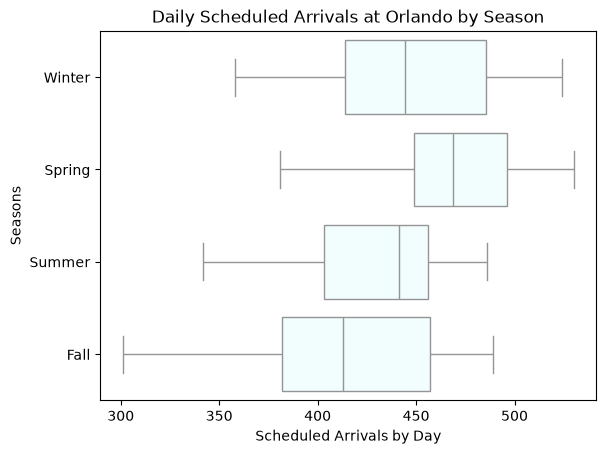

In [34]:
sns.boxplot(data=orlando,
             x = 'scheduled_arrivals',
             y = 'season',
             order = season_order,
             color = 'azure')

plt.title('Daily Scheduled Arrivals at Orlando by Season')
plt.xlabel("Scheduled Arrivals by Day")
plt.ylabel('Seasons')
plt.show()

## Discussion: compare the seasonal box plots

What differences among the four seasons are easier to see in the box plots than in the histogram?


### Violin plots


## Discussion: compare the seasonal violin plots

What does the violin plot add to the seasonal comparison? What remains difficult to interpret?


## Discussion: choose the clearest figure

Which figure does the clearest job of comparing the number of scheduled arrivals by season? Explain your choice.


## Step 6 — Conclusion

Spring was Orlando's busiest season by the typical number of scheduled arrivals per day in 2025. The spring median was approximately 468.5 scheduled arrivals per day, compared with 444.5 in winter, 441.5 in summer, and 413.0 in fall. Spring also had the highest mean at about 465.7 scheduled arrivals per day. The distributions overlap, so not every spring day was busier than every day in another season.


## Step 7 — Limitation

- The analysis describes only 2025, so it cannot establish a recurring seasonal pattern.
- Meteorological seasons are course-defined categories; another definition could change membership near the boundaries.
- Season is associated with many changing conditions, including holidays, school calendars, weather, airline schedules, and tourism demand.
- Scheduled arrivals describe planned flight volume, not passenger counts, completed flights, or airport capacity use.
- Each row summarizes one date, so the analysis cannot explain differences among individual flights.
- The comparison does not establish that spring itself caused higher scheduled traffic.


## Discussion: compare the seasonal distributions

1. The seasons contain between 90 and 92 days. Why could comparing seasonal totals make a longer season appear busier simply because it contains more days?

2. Does “spring was busiest” mean that every spring day had more scheduled arrivals than every day in another season?

3. What does the scheduled-arrival feature measure, and what does it leave out?

4. Why is one year insufficient to claim that spring is always Orlando's busiest season?


## Key takeaways

- Define precisely what one observation and one quantitative value represent.
- Confirm that values, units, and exclusions match the research question.
- Histograms, box plots, and violin plots emphasize different distribution features.
- Compare center, spread, shape, overlap, and unusual values—not only averages.
- Conclusions should describe association, not unsupported causation.
- Pandas datetime tools can turn dates into analytically useful calendar categories.
- When groups contain different numbers of days, compare daily distributions rather than letting unequal group sizes determine a total.
